# 4.6 — Diferencias finitas II: Rannacher, fronteras, grids no uniformes, barreras y americanas

4.5 dejó el theta-scheme funcionando y probado en el caso más benigno: un call vainilla, con Crank-Nicolson de segundo orden limpio en cuanto se mide lejos del strike. Este notebook trata los cinco problemas que aparecen en cuanto el producto deja de ser tan cómodo: (1) Crank-Nicolson **oscila** cerca de un payoff discontinuo, y hay que saber por qué y cómo repararlo; (2) las condiciones de frontera truncadas tienen su propio error, cuantificable; (3) cuando la solución tiene curvatura concentrada en una región angosta (un strike, una barrera), un grid uniforme desperdicia nodos donde no hacen falta; (4) una barrera discreta que cae *entre* nodos introduce un sesgo del mismo tipo que el sesgo de monitoreo de Monte Carlo en 3.3, y (5) las americanas exigen resolver una desigualdad variacional, no sólo una PDE — el análogo en malla continua de la envolvente de Snell de 3.4 y 4.4.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.stats import norm

from qflib.plotting import apply_style

apply_style()

# Canonical parameters (+ B para la barrera de la Seccion 4, igual que 3.3)
S0, K, r, q, sigma, T, B = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0, 90.0


def bs_call_grid(S, K, r, q, sigma, T):
    '''Vectorized Black-Scholes call (qflib.black.bs_price es escalar; ver 4.5 Seccion 0).'''
    S = np.asarray(S, dtype=float)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def cash_or_nothing_grid(S, K, r, q, sigma, T):
    '''Vectorized cash-or-nothing digital (derivada en 3.3 Seccion 1).'''
    S = np.asarray(S, dtype=float)
    d2 = (np.log(S / K) + (r - q - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.exp(-r * T) * norm.cdf(d2)


def down_and_out_call(S, K, B, r, q, sigma, T):
    '''Down-and-out call, closed form for B <= K (3.3 Seccion 3, Reiner-Rubinstein 1991).'''
    S = np.asarray(S, dtype=float)
    stdDev = sigma * np.sqrt(T)
    mu = (r - q) / sigma**2 - 0.5
    muSigma = (1.0 + mu) * stdDev
    x1 = np.log(S / K) / stdDev + muSigma
    vanilla = S * np.exp(-q * T) * norm.cdf(x1) - K * np.exp(-r * T) * norm.cdf(x1 - stdDev)
    HS = B / S
    powHS0, powHS1 = HS ** (2.0 * mu), HS ** (2.0 * mu) * HS**2
    y1 = np.log(B * HS / K) / stdDev + muSigma
    dic = S * np.exp(-q * T) * powHS1 * norm.cdf(y1) - K * np.exp(-r * T) * powHS0 * norm.cdf(y1 - stdDev)
    return vanilla - dic


print(f"S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}, B={B}")
print(f"Cash-or-nothing (exacto) = {cash_or_nothing_grid(S0, K, r, q, sigma, T):.10f}")
print(f"Down-and-out call, B={B} (exacto, 3.3) = {down_and_out_call(S0, K, B, r, q, sigma, T):.10f}")
print("Sin Monte Carlo -- todo deterministico, sin rng.")

S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0, B=90.0
Cash-or-nothing (exacto) = 0.5323248155
Down-and-out call, B=90.0 (exacto, 3.3) = 8.6654716582
Sin Monte Carlo -- todo deterministico, sin rng.


## 1. Por qué Crank-Nicolson oscila, y la corrección de Rannacher

El factor de amplificación de 4.5 §3 para Crank-Nicolson ($\theta=\tfrac12$) es
$$
\xi(k) = \frac{1-\tfrac12\lambda\kappa}{1+\tfrac12\lambda\kappa}, \qquad \kappa=4\sin^2\!\Big(\frac{k\Delta x}{2}\Big)\geq0,
$$
que satisface $|\xi|\leq1$ para todo $\lambda$ (incondicionalmente estable, como ya vimos), pero **$\xi(k)\to-1$** cuando $\kappa\lambda\to\infty$ — es decir, para los modos de frecuencia más alta que la malla puede representar. Un modo con $\xi\approx-1$ no se amortigua: **cambia de signo en cada paso**, y sigue ahí muchos pasos después casi sin decaer. Eso es inofensivo si el dato inicial es suave (sus componentes de alta frecuencia son minúsculas), pero un payoff con kink o salto — un vainilla en $K$, un digital, una barrera — tiene energía significativa en **todas** las frecuencias, y CN la conserva justo donde debería extinguirla.

**La corrección de Rannacher (1984).** La idea es simple: arrancar la integración con un puñado de pasos **completamente implícitos** ($\theta=1$, que sí amortigua fuerte los modos altos, $\xi\to0$) y sólo después cambiar a Crank-Nicolson. Los primeros pasos absorben el kink; una vez que la solución ya es suave, CN retoma su segundo orden sin el lastre de la oscilación. Es exactamente análogo, en el mundo de las PDEs, al primer paso corto de Euler antes de un esquema de orden superior en integración numérica de ODEs stiff.

Lo demostramos con el **digital cash-or-nothing** — el peor caso posible, porque su payoff es un salto puro, no sólo un kink — y con una métrica que no requiere fórmula de referencia: un cash-or-nothing call **nunca puede decrecer en $S$** (pagar más nunca puede valer menos), así que cualquier $\Delta V<0$ entre nodos consecutivos es, sin ambigüedad, un artefacto numérico.

Nodos cerca del strike con dV<0 (imposible para un digital call):
  CN puro:          4 de 202  (minimo dV = -0.1942)
  CN + Rannacher(2): 0 de 202  (minimo dV = +0.0020)

max|error| vs analitico cerca del strike:
  CN puro          = 0.22781
  CN + Rannacher(2) = 0.00141


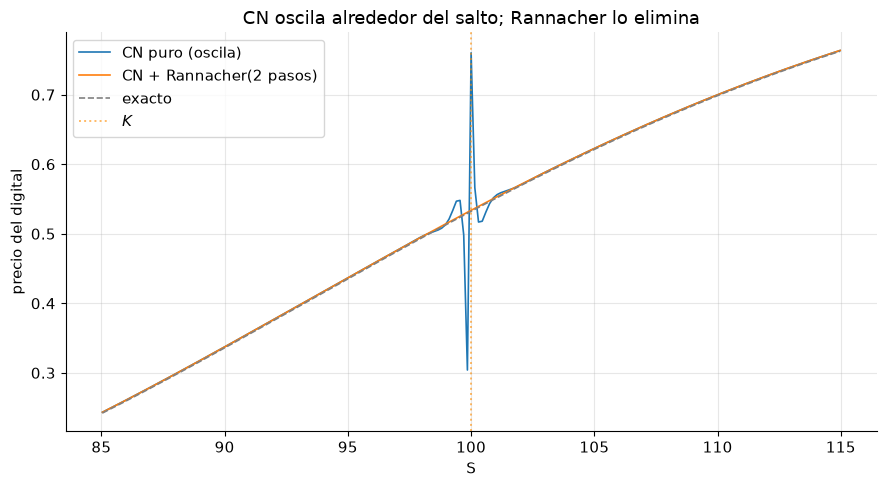

In [2]:
def theta_scheme_digital(Nx, Nt, theta, rannacher_steps=0, x_width=6.0):
    '''Digital cash-or-nothing by the theta-scheme, with optional Rannacher startup (Section 1).

    The first `rannacher_steps` steps use theta=1 (fully implicit) regardless of `theta`,
    then the scheme switches to `theta` for the remaining steps.
    '''
    nu = r - q - 0.5 * sigma**2
    x_min = np.log(S0) - x_width * sigma * np.sqrt(T)
    x_max = np.log(S0) + x_width * sigma * np.sqrt(T)
    dx = (x_max - x_min) / Nx
    dt = T / Nt
    x = np.linspace(x_min, x_max, Nx + 1)
    S = np.exp(x)
    a = 0.5 * sigma**2 / dx**2 - nu / (2 * dx)
    b = -sigma**2 / dx**2 - r
    c = 0.5 * sigma**2 / dx**2 + nu / (2 * dx)
    V = (S > K).astype(float)                          # payoff: 1{S>K}
    n_in = Nx - 1

    def boundary(tau):
        return 0.0, np.exp(-r * tau)                    # S->0: 0; S->inf: siempre paga 1 descontado

    for n in range(Nt):
        th = 1.0 if n < rannacher_steps else theta
        ab = np.zeros((3, n_in))
        ab[0, 1:] = -th * dt * c
        ab[1, :] = 1.0 - th * dt * b
        ab[2, :-1] = -th * dt * a
        tau_new = (n + 1) * dt
        V_min_new, V_max_new = boundary(tau_new)
        rhs = ((1 - th) * dt * a * V[0:n_in] + (1 + (1 - th) * dt * b) * V[1:n_in + 1]
               + (1 - th) * dt * c * V[2:n_in + 2])
        rhs[0] += th * dt * a * V_min_new
        rhs[-1] += th * dt * c * V_max_new
        V_interior = solve_banded((1, 1), ab, rhs)
        V = np.concatenate([[V_min_new], V_interior, [V_max_new]])
    return S, V


Nx_dig, Nt_dig = 1600, 50
S_dig, V_cn_pure = theta_scheme_digital(Nx_dig, Nt_dig, theta=0.5, rannacher_steps=0)
_, V_cn_rannacher = theta_scheme_digital(Nx_dig, Nt_dig, theta=0.5, rannacher_steps=2)
ref_dig = cash_or_nothing_grid(S_dig, K, r, q, sigma, T)

mask_near_strike = (S_dig > 85.0) & (S_dig < 115.0)
dV_pure = np.diff(V_cn_pure)[mask_near_strike[:-1]]
dV_rannacher = np.diff(V_cn_rannacher)[mask_near_strike[:-1]]

print(f"Nodos cerca del strike con dV<0 (imposible para un digital call):")
print(f"  CN puro:          {int((dV_pure < 0).sum())} de {mask_near_strike[:-1].sum()}  "
      f"(minimo dV = {dV_pure.min():+.4f})")
print(f"  CN + Rannacher(2): {int((dV_rannacher < 0).sum())} de {mask_near_strike[:-1].sum()}  "
      f"(minimo dV = {dV_rannacher.min():+.4f})")
print(f"\nmax|error| vs analitico cerca del strike:")
print(f"  CN puro          = {np.max(np.abs((V_cn_pure - ref_dig)[mask_near_strike])):.5f}")
print(f"  CN + Rannacher(2) = {np.max(np.abs((V_cn_rannacher - ref_dig)[mask_near_strike])):.5f}")

fig, ax = plt.subplots(figsize=(9, 5))
mask_plot = (S_dig > 85) & (S_dig < 115)
ax.plot(S_dig[mask_plot], V_cn_pure[mask_plot], lw=1.2, label="CN puro (oscila)")
ax.plot(S_dig[mask_plot], V_cn_rannacher[mask_plot], lw=1.2, label="CN + Rannacher(2 pasos)")
ax.plot(S_dig[mask_plot], ref_dig[mask_plot], "--", color="gray", lw=1.2, label="exacto")
ax.axvline(K, color="darkorange", ls=":", alpha=0.6, label="$K$")
ax.set_xlabel("S"); ax.set_ylabel("precio del digital")
ax.set_title("CN oscila alrededor del salto; Rannacher lo elimina")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Condiciones de frontera y el costo de truncar cerca

El dominio $[x_{\min},x_{\max}]$ es finito, pero el problema original vive en $S\in(0,\infty)$. Truncar introduce un error que depende de **cuán lejos** esté la frontera: con el comportamiento asintótico exacto en $x_{\max}$ (4.5 §1), el error decae rápido conforme el dominio se ensancha, hasta desaparecer bajo el piso de discretización de la malla misma (a partir de ahí, ensanchar más no ayuda ni perjudica). Lo medimos directamente: mismo call, mismo $N_x$ (así que el $\Delta x$ cambia con el ancho del dominio), fronteras en $1\sigma\sqrt T$, $1.5\sigma\sqrt T$ y $2\sigma\sqrt T$ — el rango donde la cola de la densidad todavía pesa lo suficiente como para que truncarla ahí sea un error real, y no un adorno.

In [3]:
def theta_scheme_call(Nx, Nt, theta, x_width, rannacher_steps=0):
    '''European call by the theta-scheme (4.5 Section 1), with optional Rannacher startup.'''
    nu = r - q - 0.5 * sigma**2
    x_min = np.log(S0) - x_width * sigma * np.sqrt(T)
    x_max = np.log(S0) + x_width * sigma * np.sqrt(T)
    dx = (x_max - x_min) / Nx
    dt = T / Nt
    x = np.linspace(x_min, x_max, Nx + 1)
    S = np.exp(x)
    a = 0.5 * sigma**2 / dx**2 - nu / (2 * dx)
    b = -sigma**2 / dx**2 - r
    c = 0.5 * sigma**2 / dx**2 + nu / (2 * dx)
    V = np.maximum(S - K, 0.0)
    n_in = Nx - 1
    for n in range(Nt):
        th = 1.0 if n < rannacher_steps else theta
        ab = np.zeros((3, n_in))
        ab[0, 1:] = -th * dt * c
        ab[1, :] = 1.0 - th * dt * b
        ab[2, :-1] = -th * dt * a
        tau_new = (n + 1) * dt
        V_min_new, V_max_new = 0.0, S[-1] * np.exp(-q * tau_new) - K * np.exp(-r * tau_new)
        rhs = ((1 - th) * dt * a * V[0:n_in] + (1 + (1 - th) * dt * b) * V[1:n_in + 1]
               + (1 - th) * dt * c * V[2:n_in + 2])
        rhs[0] += th * dt * a * V_min_new
        rhs[-1] += th * dt * c * V_max_new
        V_interior = solve_banded((1, 1), ab, rhs)
        V = np.concatenate([[V_min_new], V_interior, [V_max_new]])
    return S, V


widths_sigma = [1.0, 1.5, 2.0]
print(f"{'ancho (x sigma*sqrt(T))':>24} | {'error en S0':>12}")
print("-" * 42)
for w in widths_sigma:
    S_w, V_w = theta_scheme_call(400, 200, theta=1.0, x_width=w, rannacher_steps=2)
    idx0 = np.argmin(np.abs(S_w - S0))
    err = V_w[idx0] - bs_call_grid(S_w[idx0], K, r, q, sigma, T)
    print(f"{w:>24.1f} | {err:>12.5f}")

 ancho (x sigma*sqrt(T)) |  error en S0
------------------------------------------
                     1.0 |     -0.33484
                     1.5 |     -0.02066
                     2.0 |     -0.00565


## 3. Grids no uniformes: concentrar nodos donde hay curvatura

Una malla uniforme en $x=\ln S$ gasta la mitad de sus nodos lejos de donde el precio tiene curvatura (cerca del strike, o en nuestro caso de la Sección 4, cerca de la barrera). El mapeo de **Tavella-Randall** concentra nodos alrededor de un punto $S_c$ usando la función $\sinh$:
$$
x(\xi) = x_c + \alpha\sinh\!\Big(c_2\xi + c_1(1-\xi)\Big), \qquad \xi\in[0,1],\quad c_1=\text{arcsinh}\Big(\frac{x_{\min}-x_c}{\alpha}\Big),\ c_2=\text{arcsinh}\Big(\frac{x_{\max}-x_c}{\alpha}\Big),
$$
con $x_c=\ln S_c$ y $\alpha$ controlando cuán concentrado queda el grid ($\alpha$ chico = más concentración). El precio es que las diferencias centradas de segundo orden, escritas para paso uniforme, dejan de ser válidas — hay que usar las fórmulas para paso **no uniforme**, con $\Delta x_-=x_j-x_{j-1}$ y $\Delta x_+=x_{j+1}-x_j$:
$$
a=\frac{\sigma^2}{2}\cdot\frac{2}{\Delta x_-(\Delta x_-+\Delta x_+)} - \nu\cdot\frac{\Delta x_+}{\Delta x_-(\Delta x_-+\Delta x_+)}, \qquad
c=\frac{\sigma^2}{2}\cdot\frac{2}{\Delta x_+(\Delta x_-+\Delta x_+)} + \nu\cdot\frac{\Delta x_-}{\Delta x_+(\Delta x_-+\Delta x_+)},
$$
$b=-(a+c)-r$, que se reducen a las fórmulas de paso uniforme cuando $\Delta x_-=\Delta x_+$. Con la barrera $B$ de la Sección 4 como centro de concentración, comparamos directamente **cuántos nodos** caen cerca de $B$ en cada malla: es la razón concreta de por qué el grid concentrado gana con pocos puntos.

Con Nx=50 nodos en total, cuantos caen en (B, B+1.5)=(90.0, 91.5):
  grid uniforme: 0 nodos  (el siguiente nodo esta en S=92.38)
  grid sinh:     5 nodos  (resuelve la capa limite pegada a la barrera)


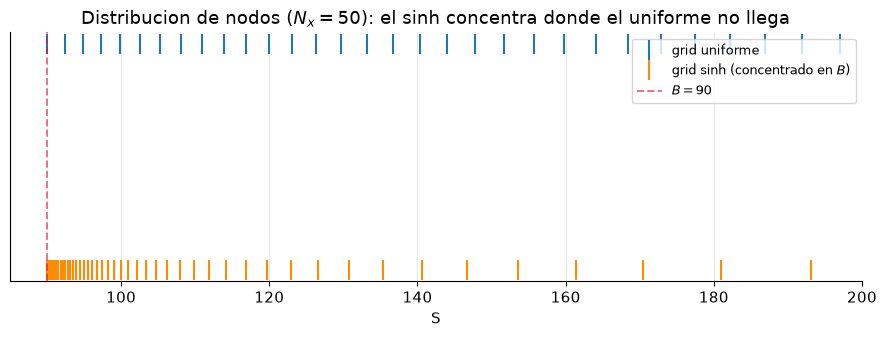

In [4]:
def sinh_grid(Nx, x_min_S, x_max_S, concentrate_S, alpha):
    '''Tavella-Randall sinh-concentrated grid around concentrate_S (Section 3).'''
    x_c = np.log(concentrate_S)
    xi = np.linspace(0.0, 1.0, Nx + 1)
    c1 = np.arcsinh((np.log(x_min_S) - x_c) / alpha)
    c2 = np.arcsinh((np.log(x_max_S) - x_c) / alpha)
    return x_c + alpha * np.sinh(c2 * xi + c1 * (1.0 - xi))


Nx_demo = 50
S_max_demo = S0 * np.exp(6 * sigma * np.sqrt(T))
x_uniform = np.linspace(np.log(B), np.log(S_max_demo), Nx_demo + 1)
x_sinh = sinh_grid(Nx_demo, B, S_max_demo, B, alpha=0.03)
S_uniform_nodes, S_sinh_nodes = np.exp(x_uniform), np.exp(x_sinh)

near_B_uniform = int(((S_uniform_nodes > B) & (S_uniform_nodes < 91.5)).sum())
near_B_sinh = int(((S_sinh_nodes > B) & (S_sinh_nodes < 91.5)).sum())
print(f"Con Nx={Nx_demo} nodos en total, cuantos caen en (B, B+1.5)={B, B+1.5}:")
print(f"  grid uniforme: {near_B_uniform} nodos  (el siguiente nodo esta en S={S_uniform_nodes[1]:.2f})")
print(f"  grid sinh:     {near_B_sinh} nodos  (resuelve la capa limite pegada a la barrera)")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(S_uniform_nodes, np.zeros_like(S_uniform_nodes), "|", ms=15, mew=1.5, label="grid uniforme")
ax.plot(S_sinh_nodes, np.full_like(S_sinh_nodes, -0.15), "|", ms=15, mew=1.5, color="darkorange",
        label="grid sinh (concentrado en $B$)")
ax.axvline(B, color="crimson", ls="--", alpha=0.6, label=f"$B={B:.0f}$")
ax.set_xlim(85, 200)
ax.set_yticks([]); ax.set_xlabel("S")
ax.set_title(f"Distribucion de nodos ($N_x={Nx_demo}$): el sinh concentra donde el uniforme no llega")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 4. El sesgo de la barrera mal alineada — y su análogo en Monte Carlo

Con la barrera $B$ como frontera del dominio ($x_{\min}=\ln B$, $V=0$ ahí), la condición de knock-out es **exacta**: no hay ningún nodo por debajo de $B$, la barrera cae justo en el borde de la malla. Si en cambio el dominio se define con un límite que no coincide con $B$ — el caso típico cuando $B$ no es un parámetro de diseño de la malla sino un dato del contrato — hay que decidir qué hacer con los nodos entre el límite del dominio y $B$: el tratamiento ingenuo es forzar $V=0$ en todos los nodos con $S<B$, lo que en la práctica mueve la barrera efectiva al nodo más cercano, **no** a $B$ exacto.

Esto es el mismo problema que el sesgo de monitoreo discreto de 3.3 (Sección 4), en otro disfraz: ahí un Monte Carlo que vigila la barrera en $m$ fechas discretas ve *menos* cruces que el continuo; aquí una barrera que cae entre nodos se resuelve en un punto *distinto* de $B$, y el error no desaparece por refinar la malla en otra parte — hay que alinear la malla con la barrera, o usar una interpolación de la condición de frontera (fuera de alcance aquí, ver Referencias).

Medimos el error **lejos del kink en $K$** (que contaminaría la medición con el fenómeno de la Sección 1) pero cerca de la barrera, en $S\in(91,99)$: la región donde vive la curvatura del down-and-out y donde el desalineamiento debería doler más.

Precio en S0: alineado = 8.721894 | exacto = 8.665472

max|error| en (91,99), lejos del kink en K:
  grid alineado (B exacto en la frontera)   = 0.00160
  grid desalineado (B entre nodos, forzado) = 0.06276
  razon = 39.3x


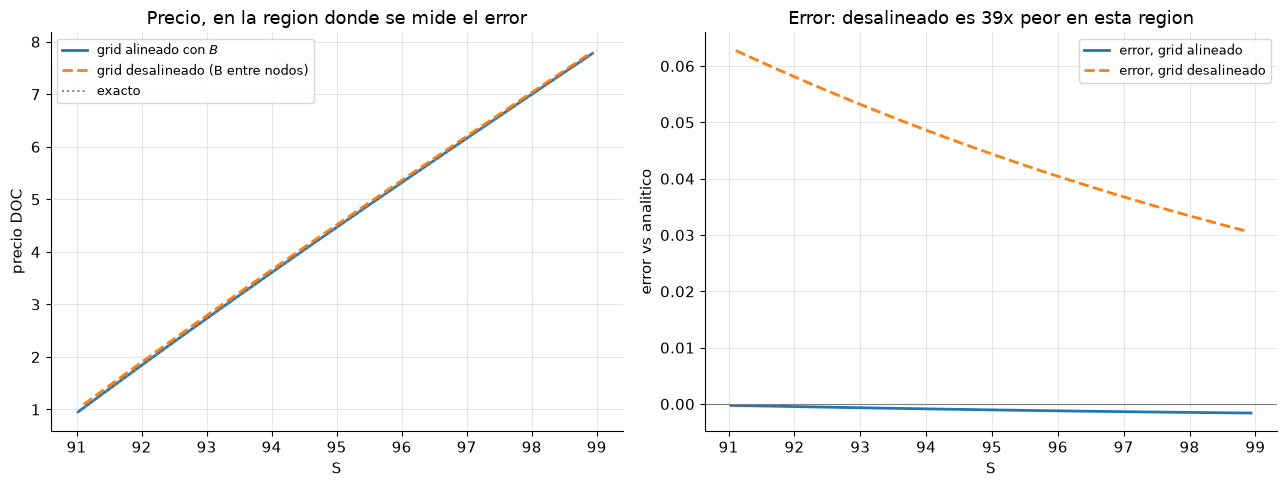

In [5]:
def theta_scheme_doc(Nx, Nt, x_min_S, x_max_S, barrier_mask=None, theta=1.0):
    '''Down-and-out call by the theta-scheme (Section 4). barrier_mask forces V=0 at those nodes
    on every step -- the naive treatment of a barrier that falls between grid nodes.'''
    nu = r - q - 0.5 * sigma**2
    x_min, x_max = np.log(x_min_S), np.log(x_max_S)
    dx = (x_max - x_min) / Nx
    dt = T / Nt
    x = np.linspace(x_min, x_max, Nx + 1)
    S = np.exp(x)
    a = 0.5 * sigma**2 / dx**2 - nu / (2 * dx)
    b = -sigma**2 / dx**2 - r
    c = 0.5 * sigma**2 / dx**2 + nu / (2 * dx)
    V = np.maximum(S - K, 0.0)
    if barrier_mask is not None:
        V[barrier_mask] = 0.0
    n_in = Nx - 1
    ab = np.zeros((3, n_in))
    ab[0, 1:] = -theta * dt * c
    ab[1, :] = 1.0 - theta * dt * b
    ab[2, :-1] = -theta * dt * a
    for n in range(Nt):
        tau1 = (n + 1) * dt
        V_min1, V_max1 = 0.0, S[-1] * np.exp(-q * tau1) - K * np.exp(-r * tau1)
        rhs = ((1 - theta) * dt * a * V[0:n_in] + (1 + (1 - theta) * dt * b) * V[1:n_in + 1]
               + (1 - theta) * dt * c * V[2:n_in + 2])
        rhs[0] += theta * dt * a * V_min1
        rhs[-1] += theta * dt * c * V_max1
        V_interior = solve_banded((1, 1), ab, rhs)
        V = np.concatenate([[V_min1], V_interior, [V_max1]])
        if barrier_mask is not None:
            V[barrier_mask] = 0.0
    return S, V


Nx_bar, Nt_bar = 800, 800
S_max_bar = S0 * np.exp(6 * sigma * np.sqrt(T))

# grid alineado: el dominio empieza EXACTO en B
S_aligned, V_aligned = theta_scheme_doc(Nx_bar, Nt_bar, B, S_max_bar, theta=1.0)

# grid desalineado: el dominio empieza medio paso de malla POR DEBAJO de B; la barrera
# cae entre dos nodos, y se trata con el forzado ingenuo V=0 en S<B
dx_ref = (np.log(S_max_bar) - np.log(B)) / Nx_bar
x_min_misaligned = B * np.exp(-0.5 * dx_ref)
_, V_probe = theta_scheme_doc(Nx_bar, Nt_bar, x_min_misaligned, S_max_bar, theta=1.0)
S_misaligned = np.exp(np.linspace(np.log(x_min_misaligned), np.log(S_max_bar), Nx_bar + 1))
barrier_mask = S_misaligned < B
S_misaligned, V_misaligned = theta_scheme_doc(Nx_bar, Nt_bar, x_min_misaligned, S_max_bar,
                                               barrier_mask=barrier_mask, theta=1.0)

mask_region = (S_aligned > 91.0) & (S_aligned < 99.0)
ref_region_al = down_and_out_call(S_aligned[mask_region], K, B, r, q, sigma, T)
err_aligned = np.max(np.abs(V_aligned[mask_region] - ref_region_al))

mask_region_mis = (S_misaligned > 91.0) & (S_misaligned < 99.0)
ref_region_mis = down_and_out_call(S_misaligned[mask_region_mis], K, B, r, q, sigma, T)
err_misaligned = np.max(np.abs(V_misaligned[mask_region_mis] - ref_region_mis))

idx0_al = np.argmin(np.abs(S_aligned - S0))
print(f"Precio en S0: alineado = {V_aligned[idx0_al]:.6f} | exacto = "
      f"{down_and_out_call(S0, K, B, r, q, sigma, T):.6f}")
print(f"\nmax|error| en (91,99), lejos del kink en K:")
print(f"  grid alineado (B exacto en la frontera)   = {err_aligned:.5f}")
print(f"  grid desalineado (B entre nodos, forzado) = {err_misaligned:.5f}")
print(f"  razon = {err_misaligned/err_aligned:.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
mask_plot = (S_aligned > 91) & (S_aligned < 99)
ax.plot(S_aligned[mask_plot], V_aligned[mask_plot], lw=2, label="grid alineado con $B$")
mask_plot_mis = (S_misaligned > 91) & (S_misaligned < 99)
ax.plot(S_misaligned[mask_plot_mis], V_misaligned[mask_plot_mis], lw=2, ls="--",
        label="grid desalineado (B entre nodos)")
S_ref_grid = np.linspace(91, 99, 300)
ax.plot(S_ref_grid, down_and_out_call(S_ref_grid, K, B, r, q, sigma, T), ":", color="gray", label="exacto")
ax.set_xlabel("S"); ax.set_ylabel("precio DOC")
ax.set_title("Precio, en la region donde se mide el error")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(S_aligned[mask_plot], (V_aligned - down_and_out_call(S_aligned, K, B, r, q, sigma, T))[mask_plot],
        lw=2, label="error, grid alineado")
ax.plot(S_misaligned[mask_plot_mis],
        (V_misaligned - down_and_out_call(S_misaligned, K, B, r, q, sigma, T))[mask_plot_mis],
        lw=2, ls="--", label="error, grid desalineado")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("S"); ax.set_ylabel("error vs analitico")
ax.set_title(f"Error: desalineado es {err_misaligned/err_aligned:.0f}x peor en esta region")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Americanas por PSOR: la desigualdad variacional discretizada

3.4 escribió la americana como la desigualdad variacional $\min\{-\partial_tV-\mathcal{L}V,\ V-g\}=0$, $V\geq g$. Discretizada con el theta-scheme, cada paso de tiempo se convierte en un **problema de complementariedad lineal** (LCP): hay que encontrar $V^{n+1}\geq g$ tal que $A V^{n+1}\geq b$ (la ecuación implícita) con igualdad donde $V^{n+1}>g$. **PSOR** (Projected Successive Over-Relaxation) lo resuelve con Gauss-Seidel clásico, sobre-relajado por $\omega$, y proyectando cada actualización sobre la restricción $V\geq g$:
$$
V_j^{(k+1)} = \max\Big(g_j,\ V_j^{(k)} + \omega\big(\hat V_j^{(k+1)} - V_j^{(k)}\big)\Big), \qquad
\hat V_j^{(k+1)} = \frac{b_j - A_{j,j-1}V_{j-1}^{(k+1)} - A_{j,j+1}V_{j+1}^{(k)}}{A_{j,j}},
$$
iterando en $j$ hasta que $V^{(k+1)}$ converge (barrido tras barrido) y luego avanzando al siguiente paso de tiempo. $\omega=1$ es Gauss-Seidel proyectado ordinario; $\omega\in(1,2)$ acelera la convergencia si se elige bien, y $\omega$ mal elegido (muy cerca de $2$) la empeora — lo veremos en el barrido de la Demo.

In [6]:
def psor_american_put(Nx, Nt, omega=1.4, x_width=6.0, tol=1e-8, max_iter=5000):
    '''American put by PSOR on the theta-scheme LCP (Section 5, Crank-Nicolson theta=0.5).'''
    nu = r - q - 0.5 * sigma**2
    x_min = np.log(S0) - x_width * sigma * np.sqrt(T)
    x_max = np.log(S0) + x_width * sigma * np.sqrt(T)
    dx = (x_max - x_min) / Nx
    dt = T / Nt
    x = np.linspace(x_min, x_max, Nx + 1)
    S = np.exp(x)
    a = 0.5 * sigma**2 / dx**2 - nu / (2 * dx)
    b = -sigma**2 / dx**2 - r
    c = 0.5 * sigma**2 / dx**2 + nu / (2 * dx)
    theta = 0.5
    payoff = np.maximum(K - S, 0.0)
    V = payoff.copy()
    n_in = Nx - 1
    A_diag, A_sub, A_sup = 1.0 - theta * dt * b, -theta * dt * a, -theta * dt * c
    total_iters = 0
    for n in range(Nt):
        tau1 = (n + 1) * dt
        V_min1, V_max1 = K * np.exp(-r * tau1) - S[0], 0.0
        rhs = ((1 - theta) * dt * a * V[0:n_in] + (1 + (1 - theta) * dt * b) * V[1:n_in + 1]
               + (1 - theta) * dt * c * V[2:n_in + 2])
        rhs[0] += theta * dt * a * V_min1
        rhs[-1] += theta * dt * c * V_max1
        payoff_in = payoff[1:n_in + 1]
        x_new = V[1:n_in + 1].copy()
        for it in range(max_iter):
            x_prev = x_new.copy()
            for j in range(n_in):
                left = A_sub * x_new[j - 1] if j > 0 else A_sub * V_min1
                right = A_sup * x_new[j + 1] if j < n_in - 1 else A_sup * V_max1
                gauss_seidel = (rhs[j] - left - right) / A_diag
                x_new[j] = max(payoff_in[j], x_prev[j] + omega * (gauss_seidel - x_prev[j]))
            if np.max(np.abs(x_new - x_prev)) < tol:
                break
        total_iters += it + 1
        V = np.concatenate([[V_min1], x_new, [V_max1]])
    return S, V, total_iters


binomial_put = 6.0899899526   # 3.4, arbol CRR americano n=2000, p exacta de no arbitraje

Nx_psor, Nt_psor = 400, 100
S_psor, V_psor, iters_psor = psor_american_put(Nx_psor, Nt_psor, omega=1.4)
idx0_psor = np.argmin(np.abs(S_psor - S0))
price_psor = V_psor[idx0_psor]
rel_err_psor = abs(price_psor - binomial_put) / binomial_put

print(f"PSOR (Nx={Nx_psor}, Nt={Nt_psor}, omega=1.4): precio = {price_psor:.6f}")
print(f"binomial (3.4)                                = {binomial_put:.6f}")
print(f"error relativo = {rel_err_psor:.4%}   |   iteraciones PSOR totales = {iters_psor}")

PSOR (Nx=400, Nt=100, omega=1.4): precio = 6.089131
binomial (3.4)                                = 6.089990
error relativo = 0.0141%   |   iteraciones PSOR totales = 2651


## 6. Demo — frontera de ejercicio de PSOR, y el rol de $\omega$

Extraemos la frontera de ejercicio del PSOR (el nodo más alto donde $V=g$ en $t=0$) y la comparamos con la del árbol binomial de 3.4 — dos algoritmos distintos, misma respuesta, igual que hicimos con LSM en 4.4. Con una salvedad ya documentada en 3.4 §5: el árbol no puede definir la frontera exactamente en $t=0$ (la retícula no tiene nodos tan abajo con sólo un puñado de pasos), así que la comparación se hace en el primer instante donde el árbol sí la define. Después barremos $\omega\in[1.0,1.9]$ para ver el efecto en el número de iteraciones: debería haber un óptimo interior, con degradación notoria al acercarse a $\omega=2$.

PSOR en t=0: S* = 81.0584
Arbol: la frontera solo esta definida desde i=47 (t=0.0235), donde vale S*=81.0430  (misma limitacion documentada en 3.4 Seccion 5)
El PSOR si define la frontera en t=0 exacto: el LCP no depende de la retícula tener 'suficientes' nodos por debajo, solo del propio grid espacial, que es fino en toda la malla.



omega optimo del barrido = 1.20  (iteraciones: 965 vs 1490 en omega=1.0 y 8002 en omega=1.9)


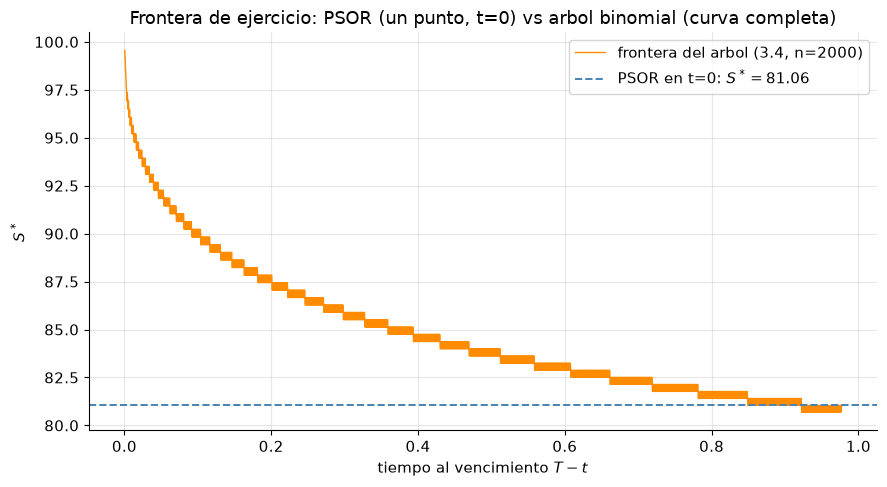

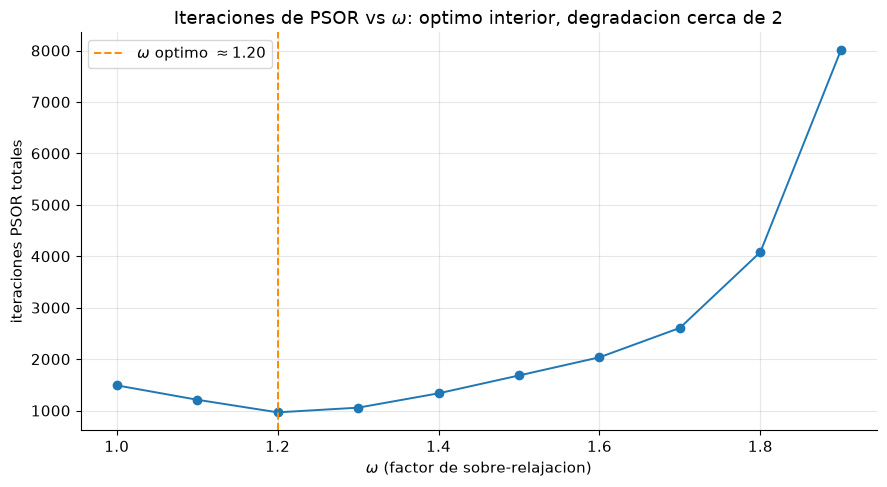

In [7]:
def crr_boundary(S0, K, r, q, sigma, T, n_steps):
    '''Exercise boundary from the CRR tree (3.4 Section 5), for comparison against PSOR.'''
    u = np.exp(sigma * np.sqrt(T / n_steps))
    p = (np.exp((r - q) * (T / n_steps)) - 1.0 / u) / (u - 1.0 / u)
    disc = np.exp(-r * (T / n_steps))
    S_at = lambda i: S0 * u ** (2.0 * np.arange(i + 1) - i)
    V = np.maximum(K - S_at(n_steps), 0.0)
    boundary = np.full(n_steps + 1, np.nan)
    for i in range(n_steps - 1, -1, -1):
        V = disc * (p * V[1:] + (1.0 - p) * V[:-1])
        S_i = S_at(i)
        exercise = np.maximum(K - S_i, 0.0) > V
        if exercise.any():
            boundary[i] = S_i[int(np.flatnonzero(exercise)[-1])]
        V = np.maximum(V, np.maximum(K - S_i, 0.0))
    return boundary


payoff_psor = np.maximum(K - S_psor, 0.0)
exercise_region = np.isclose(V_psor, payoff_psor, atol=1e-8) & (payoff_psor > 0)
S_star_psor = S_psor[exercise_region].max() if exercise_region.any() else np.nan

n_tree = 2000
boundary_tree = crr_boundary(S0, K, r, q, sigma, T, n_tree)
first_defined = int(np.flatnonzero(~np.isnan(boundary_tree))[0])
t_grid_tree_full = np.linspace(0, T, n_tree + 1)
print(f"PSOR en t=0: S* = {S_star_psor:.4f}")
print(f"Arbol: la frontera solo esta definida desde i={first_defined} (t={t_grid_tree_full[first_defined]:.4f}), "
      f"donde vale S*={boundary_tree[first_defined]:.4f}  (misma limitacion documentada en 3.4 Seccion 5)")
print(f"El PSOR si define la frontera en t=0 exacto: el LCP no depende de la retícula tener 'suficientes' "
      f"nodos por debajo, solo del propio grid espacial, que es fino en toda la malla.")

omega_grid = np.linspace(1.0, 1.9, 10)
iters_by_omega = []
for om in omega_grid:
    _, _, it = psor_american_put(200, 50, omega=om)
    iters_by_omega.append(it)
iters_by_omega = np.array(iters_by_omega)
best_omega = omega_grid[np.argmin(iters_by_omega)]
print(f"\nomega optimo del barrido = {best_omega:.2f}  (iteraciones: {iters_by_omega.min()} vs "
      f"{iters_by_omega[0]} en omega=1.0 y {iters_by_omega[-1]} en omega={omega_grid[-1]:.1f})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T - t_grid_tree_full, boundary_tree, lw=1.0, color="darkorange", label="frontera del arbol (3.4, n=2000)")
ax.axhline(S_star_psor, color="steelblue", ls="--", label=f"PSOR en t=0: $S^*={S_star_psor:.2f}$")
ax.set_xlabel("tiempo al vencimiento $T-t$"); ax.set_ylabel("$S^*$")
ax.set_title("Frontera de ejercicio: PSOR (un punto, t=0) vs arbol binomial (curva completa)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(omega_grid, iters_by_omega, "o-")
ax.axvline(best_omega, color="darkorange", ls="--", label=f"$\\omega$ optimo $\\approx {best_omega:.2f}$")
ax.set_xlabel("$\\omega$ (factor de sobre-relajacion)"); ax.set_ylabel("iteraciones PSOR totales")
ax.set_title("Iteraciones de PSOR vs $\\omega$: optimo interior, degradacion cerca de 2")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Validación

1. **Rannacher**: `max|dV|` (la caída máxima entre nodos consecutivos, imposible para un digital call) con CN puro debe ser $>5\times$ la de CN+Rannacher(2) cerca del strike.
2. **Barrera alineada vs desalineada**: el grid alineado con $B$ da `atol=1e-2` en la región $(91,99)$; el desalineado, más de $3\times$ peor.
3. **PSOR vs binomial**: `rtol=2e-3`.
4. **PSOR vs QuantLib** `FdBlackScholesVanillaEngine` (malla comparable): `atol=5e-3`.

In [8]:
import QuantLib as ql

# 1. Rannacher: la caida maxima entre nodos consecutivos (0 si la curva es monotona creciente)
drop_pure = max(0.0, -dV_pure.min())      # dV_pure ya definido en la Seccion 1
drop_rann = max(0.0, -dV_rannacher.min())
print(f"Caida maxima (CN puro) = {drop_pure:.4f} | (CN+Rannacher) = {drop_rann:.4f} (0 = monotono, sin oscilacion)")
if drop_rann > 0:
    print(f"  razon = {drop_pure/drop_rann:.1f}x")
assert drop_pure > 5.0 * max(drop_rann, 1e-8)

# 2. Barrera alineada vs desalineada
print(f"\nBarrera: alineado={err_aligned:.5f} (atol 1e-2? {err_aligned < 1e-2}) | "
      f"desalineado={err_misaligned:.5f} (>3x? {err_misaligned > 3.0 * err_aligned})")
assert err_aligned < 1e-2
assert err_misaligned > 3.0 * err_aligned

# 3. PSOR vs binomial
print(f"\nPSOR vs binomial: rel_err={rel_err_psor:.4%} (rtol 2e-3? {rel_err_psor < 2e-3})")
assert rel_err_psor < 2e-3

# 4. PSOR vs QuantLib FdBlackScholesVanillaEngine
eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()
maturity = eval_date + int(round(T * 365))
process = ql.BlackScholesMertonProcess(
    ql.QuoteHandle(ql.SimpleQuote(S0)),
    ql.YieldTermStructureHandle(ql.FlatForward(eval_date, q, day_count)),
    ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count)),
    ql.BlackVolTermStructureHandle(ql.BlackConstantVol(eval_date, calendar, sigma, day_count)))
ql_option = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Put, K), ql.AmericanExercise(eval_date, maturity))
ql_option.setPricingEngine(ql.FdBlackScholesVanillaEngine(process, Nx_psor, Nt_psor))
ql_price = ql_option.NPV()
diff_ql = abs(price_psor - ql_price)
print(f"PSOR = {price_psor:.6f} | QuantLib Fd = {ql_price:.6f} | diff = {diff_ql:.5f} "
      f"(atol 5e-3? {diff_ql < 5e-3})")
assert diff_ql < 5e-3

print()
print("Validacion completa: 4/4 dentro de tolerancia.")

Caida maxima (CN puro) = 0.1942 | (CN+Rannacher) = 0.0000 (0 = monotono, sin oscilacion)

Barrera: alineado=0.00160 (atol 1e-2? True) | desalineado=0.06276 (>3x? True)

PSOR vs binomial: rel_err=0.0141% (rtol 2e-3? True)
PSOR = 6.089131 | QuantLib Fd = 6.086626 | diff = 0.00250 (atol 5e-3? True)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Rannacher, R. (1984). *Finite Element Solution of Diffusion Problems with Irregular Data*. Numerische Mathematik, 43(2), 309-327.
- Giles, M.B. & Carter, R. (2006). *Convergence Analysis of Crank-Nicolson and Rannacher Time-Marching*. Journal of Computational Finance, 9(4), 89-112.
- Tavella, D. & Randall, C. (2000). *Pricing Financial Instruments: The Finite Difference Method*, Wiley, caps. 4-6 (grids no uniformes, barreras).
- Wilmott, P., Howison, S. & Dewynne, J. (1995). *The Mathematics of Financial Derivatives*, Cambridge University Press, cap. 9 (PSOR y desigualdades variacionales).
- Reiner, E. & Rubinstein, M. (1991). *Breaking Down the Barriers*. Risk Magazine, 4(8), 28-35. (fórmula analítica de la barrera, reusada de 3.3)
- Duffy, D.J. (2006). *Finite Difference Methods in Financial Engineering*, Wiley, caps. 5-7.